# Brain Tumor Classification using VGG16 + XGBoost

In this notebook, VGG16 is used as a feature extractor to obtain deep image representations from MRI scans. These extracted features are then used to train an XGBoost classifier for brain tumor classification.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

print("Libraries imported successfully.")

I0000 00:00:1781073545.514503    1748 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully.


## Define Dataset Paths

The Brain Tumor dataset is loaded from the training directory.
The same dataset is used as in the previous experiments, but images are prepared in a format compatible with VGG16.

In [2]:
train_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-1(BrainTumour-SVM)/archive/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

print("Classes Loaded:")
for cls in classes:
    print("-", cls)

Classes Loaded:
- no_tumor
- pituitary_tumor
- glioma_tumor
- meningioma_tumor


## Load and Preprocess Images for VGG16

Images are loaded in RGB format and resized to 224×224 pixels, which is the input size expected by the VGG16 architecture.
The images will later be passed through VGG16 to extract deep features.

In [3]:
IMG_SIZE = 224

X = []
Y = []

for cls, label in classes.items():

    folder_path = os.path.join(train_path, cls)

    for filename in os.listdir(folder_path):

        image_path = os.path.join(folder_path, filename)

        img = cv2.imread(image_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        Y.append(label)

X = np.array(X, dtype=np.float32)
Y = np.array(Y)

print("Image Dataset Shape:", X.shape)
print("Label Vector Shape :", Y.shape)

Image Dataset Shape: (2870, 224, 224, 3)
Label Vector Shape : (2870,)


## Split the Dataset

The dataset is divided into training and testing sets using the same 80-20 split employed in the previous experiments.
This ensures a fair comparison between Original XGBoost, PCA + XGBoost, and VGG16 + XGBoost.

In [4]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=10,
    stratify=Y
)

print("Training Samples:", len(xtrain))
print("Testing Samples:", len(xtest))

Training Samples: 2296
Testing Samples: 574


## Load the Pretrained VGG16 Model

A pretrained VGG16 network is loaded and used as a feature extractor.
The classification layers are removed so that only deep image features are extracted.

In [5]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("VGG16 feature extractor loaded successfully.")

W0000 00:00:1781073600.052980    1748 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


VGG16 feature extractor loaded successfully.


## Prepare Images for VGG16

The MRI images are preprocessed using the same transformation that was applied during the original VGG16 training process.
This ensures compatibility with the pretrained network.

In [6]:
xtrain_vgg = preprocess_input(xtrain.copy())
xtest_vgg = preprocess_input(xtest.copy())

print("Training Shape:", xtrain_vgg.shape)
print("Testing Shape :", xtest_vgg.shape)

Training Shape: (2296, 224, 224, 3)
Testing Shape : (574, 224, 224, 3)


## Create VGG16 Feature Extractor

The original VGG16 model ends with classification layers designed for ImageNet.
For this project, we remove the classifier and use only the convolutional layers
to extract meaningful visual features from MRI scans.

In [7]:
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("Feature extractor ready.")

Feature extractor ready.


## Extract Deep Features

The MRI images are passed through the pretrained VGG16 network.
Instead of classifying the images directly, VGG16 generates deep feature maps
that capture important visual characteristics useful for tumor classification.

In [8]:
print("Extracting training features...")

xtrain_features = feature_extractor.predict(
    xtrain_vgg,
    batch_size=32,
    verbose=1
)

print("Extracting testing features...")

xtest_features = feature_extractor.predict(
    xtest_vgg,
    batch_size=32,
    verbose=1
)

Extracting training features...


W0000 00:00:1781073608.523827    1748 cpu_allocator_impl.cc:82] Allocation of 1382449152 exceeds 10% of free system memory.


72/72 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step
Extracting testing features...
18/18 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step


In [9]:
print("Training Feature Shape:", xtrain_features.shape)
print("Testing Feature Shape :", xtest_features.shape)

Training Feature Shape: (2296, 7, 7, 512)
Testing Feature Shape : (574, 7, 7, 512)


## Flatten VGG16 Features

The feature maps produced by VGG16 are multi-dimensional. Since XGBoost expects
tabular input, each feature map is flattened into a single feature vector.

In [10]:
xtrain_features = xtrain_features.reshape(
    xtrain_features.shape[0], -1
)

xtest_features = xtest_features.reshape(
    xtest_features.shape[0], -1
)

print("Training Feature Shape:", xtrain_features.shape)
print("Testing Feature Shape :", xtest_features.shape)

Training Feature Shape: (2296, 25088)
Testing Feature Shape : (574, 25088)


## Train XGBoost Classifier

The flattened VGG16 features are used as input to XGBoost. The classifier learns
to distinguish between different brain tumor categories using the deep visual
representations extracted by the pretrained network.

In [21]:
xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=4,
    random_state=42
)

eval_set = [
    (xtrain_features, ytrain),
    (xtest_features, ytest)
]

xgb_model.fit(
    xtrain_features,
    ytrain,
    eval_set=eval_set,
    verbose=True
)

print("XGBoost training completed.")

[0]	validation_0-mlogloss:1.20961	validation_1-mlogloss:1.24331
[1]	validation_0-mlogloss:1.09368	validation_1-mlogloss:1.15773
[2]	validation_0-mlogloss:0.99492	validation_1-mlogloss:1.08612
[3]	validation_0-mlogloss:0.90572	validation_1-mlogloss:1.02281
[4]	validation_0-mlogloss:0.82665	validation_1-mlogloss:0.96690
[5]	validation_0-mlogloss:0.75680	validation_1-mlogloss:0.91576
[6]	validation_0-mlogloss:0.69541	validation_1-mlogloss:0.87225
[7]	validation_0-mlogloss:0.64087	validation_1-mlogloss:0.83319
[8]	validation_0-mlogloss:0.59176	validation_1-mlogloss:0.79588
[9]	validation_0-mlogloss:0.54653	validation_1-mlogloss:0.76142
[10]	validation_0-mlogloss:0.50676	validation_1-mlogloss:0.73163
[11]	validation_0-mlogloss:0.46878	validation_1-mlogloss:0.70098
[12]	validation_0-mlogloss:0.43500	validation_1-mlogloss:0.67326
[13]	validation_0-mlogloss:0.40411	validation_1-mlogloss:0.65065
[14]	validation_0-mlogloss:0.37595	validation_1-mlogloss:0.62789
[15]	validation_0-mlogloss:0.34984	

In [22]:
results = xgb_model.evals_result()

train_loss = results["validation_0"]["mlogloss"]
val_loss = results["validation_1"]["mlogloss"]

print("Training Iterations:", len(train_loss))

Training Iterations: 120


In [23]:
train_acc = [1.0 - x for x in train_loss]
val_acc = [1.0 - x for x in val_loss]

print("Learning curves prepared.")

Learning curves prepared.


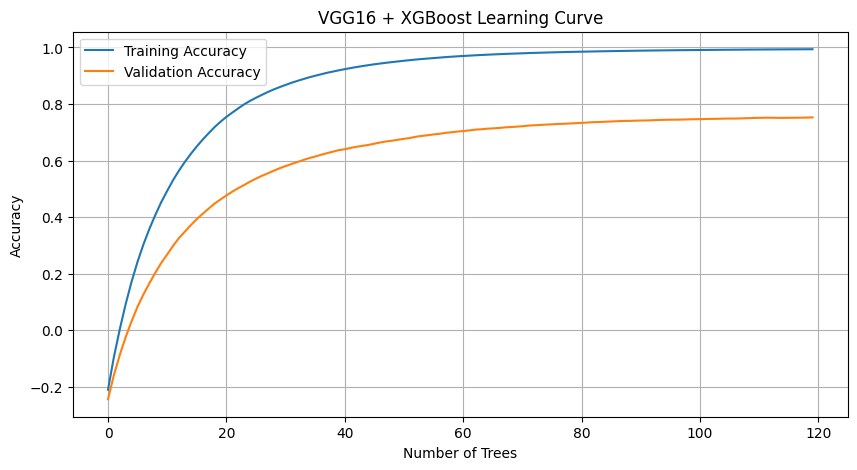

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("VGG16 + XGBoost Learning Curve")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Evaluate VGG16 + XGBoost Model

The trained XGBoost classifier is evaluated on the testing dataset. Multiple
metrics are used to measure classification performance and compare the model
with previous approaches.

In [28]:
ytrain_pred = xgb_model.predict(xtrain_features)
ytest_pred = xgb_model.predict(xtest_features)

train_accuracy = accuracy_score(ytrain, ytrain_pred)
test_accuracy = accuracy_score(ytest, ytest_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.8990


In [29]:
print("\nClassification Report:\n")
print(classification_report(ytest, ytest_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        79
           1       0.90      0.98      0.94       165
           2       0.96      0.90      0.93       165
           3       0.84      0.80      0.82       165

    accuracy                           0.90       574
   macro avg       0.90      0.90      0.90       574
weighted avg       0.90      0.90      0.90       574



In [30]:
cm = confusion_matrix(ytest, ytest_pred)

print(cm)

[[ 74   0   0   5]
 [  0 161   0   4]
 [  0   0 149  16]
 [ 10  17   6 132]]


## Confusion Matrix

The confusion matrix provides a detailed view of model predictions. Correct
predictions appear along the diagonal, while off-diagonal entries represent
misclassifications between tumor categories.

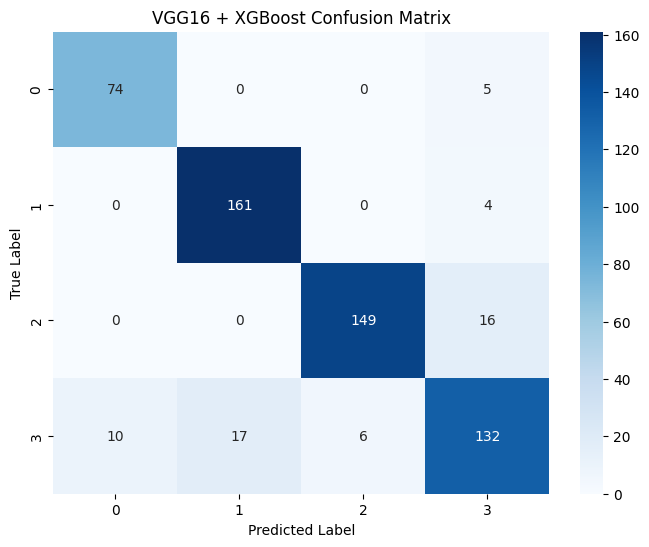

In [31]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("VGG16 + XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [32]:
f1 = f1_score(ytest, ytest_pred, average="weighted")

sensitivity = recall_score(
    ytest,
    ytest_pred,
    average="weighted"
)

cm = confusion_matrix(ytest, ytest_pred)

specificity_list = []

for i in range(len(cm)):

    tp = cm[i, i]

    fn = np.sum(cm[i, :]) - tp

    fp = np.sum(cm[:, i]) - tp

    tn = np.sum(cm) - (tp + fn + fp)

    specificity = tn / (tn + fp)

    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

print(f"Accuracy    : {test_accuracy*100:.2f}%")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Sensitivity : {sensitivity*100:.2f}%")
print(f"Specificity : {specificity*100:.2f}%")

Accuracy    : 89.90%
F1 Score    : 89.82%
Sensitivity : 89.90%
Specificity : 96.56%


In [33]:
print(xtrain_features.shape)
print(xtest_features.shape)

(2296, 25088)
(574, 25088)


## Training Percentage Experiment

To study the effect of training data size on model performance, the VGG16 +
XGBoost model is trained using 20%, 40%, 60%, and 80% of the training set.
The testing set remains unchanged for fair comparison.

In [34]:
training_sizes = [0.2, 0.4, 0.6, 0.8]

xgb_train_scores = []
xgb_test_scores = []

for size in training_sizes:

    x_small, _, y_small, _ = train_test_split(
        xtrain_features,
        ytrain,
        train_size=size,
        random_state=10,
        stratify=ytrain
    )

    xgb_model = XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        random_state=10,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )

    xgb_model.fit(x_small, y_small)

    train_acc = xgb_model.score(x_small, y_small)
    test_acc = xgb_model.score(xtest_features, ytest)

    xgb_train_scores.append(train_acc)
    xgb_test_scores.append(test_acc)

    print(f"\nTraining Size: {int(size*100)}%")
    print(f"Samples Used: {len(x_small)}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")


Training Size: 20%
Samples Used: 459
Training Accuracy: 1.0000
Testing Accuracy : 0.8519

Training Size: 40%
Samples Used: 918
Training Accuracy: 1.0000
Testing Accuracy : 0.8589

Training Size: 60%
Samples Used: 1377
Training Accuracy: 1.0000
Testing Accuracy : 0.8920

Training Size: 80%
Samples Used: 1836
Training Accuracy: 1.0000
Testing Accuracy : 0.8972


## Accuracy vs Training Percentage

The effect of training data size on model performance is visualized using an
accuracy graph. Higher training percentages generally provide the model with
more representative samples, leading to improved classification performance.

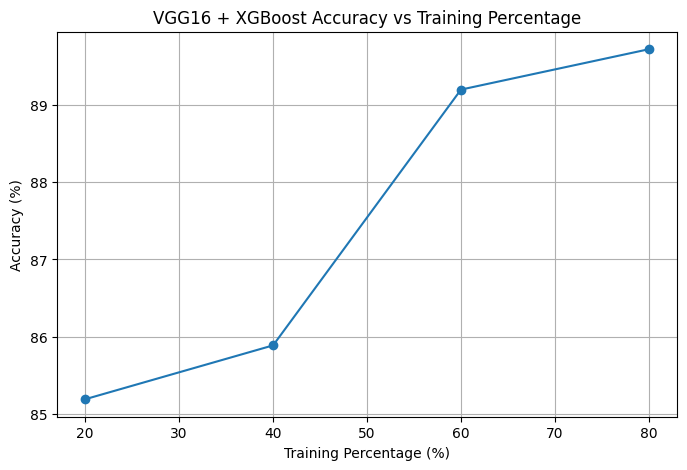

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    [20, 40, 60, 80],
    [x * 100 for x in xgb_test_scores],
    marker='o'
)

plt.title("VGG16 + XGBoost Accuracy vs Training Percentage")
plt.xlabel("Training Percentage (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()